In [17]:
!pip install spacy sklearn-crfsuite seqeval matplotlib seaborn -q
!python -m spacy download en_core_web_sm -q
print(" All packages installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 78.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
 All packages installed!


In [18]:
import re
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

import nltk
import spacy
import sklearn_crfsuite
from sklearn.metrics import accuracy_score
from seqeval.metrics import (
    classification_report as seq_report,
    f1_score as seq_f1,
    precision_score as seq_precision,
    recall_score as seq_recall,
)

warnings.filterwarnings('ignore')

for pkg in ['punkt', 'averaged_perceptron_tagger', 'punkt_tab',
            'averaged_perceptron_tagger_eng']:
    nltk.download(pkg, quiet=True)

nlp = spacy.load('en_core_web_sm')
random.seed(42)
np.random.seed(42)

print(" Libraries ready!")
print(f"   spaCy: {spacy.__version__}  |  NLTK: {nltk.__version__}")

 Libraries ready!
   spaCy: 3.8.11  |  NLTK: 3.9.1


In [19]:
ANNOTATED_DATA = [
    # ── NEWS ──────────────────────────────────────────────────────────────────
    {
        "text": "Apple Inc. announced a new product launch in Cupertino, California on Monday.",
        "entities": [
            {"text": "Apple Inc.",  "label": "ORG"},
            {"text": "Cupertino",   "label": "GPE"},
            {"text": "California",  "label": "GPE"},
            {"text": "Monday",      "label": "DATE"},
        ]
    },
    {
        "text": "Elon Musk, CEO of Tesla, visited the Berlin Gigafactory last Tuesday.",
        "entities": [
            {"text": "Elon Musk",    "label": "PERSON"},
            {"text": "Tesla",        "label": "ORG"},
            {"text": "Berlin",       "label": "GPE"},
            {"text": "last Tuesday", "label": "DATE"},
        ]
    },
    {
        "text": "Microsoft acquired Activision Blizzard for $68.7 billion in January 2023.",
        "entities": [
            {"text": "Microsoft",           "label": "ORG"},
            {"text": "Activision Blizzard", "label": "ORG"},
            {"text": "$68.7 billion",       "label": "MONEY"},
            {"text": "January 2023",        "label": "DATE"},
        ]
    },
    {
        "text": "President Biden met French leader Emmanuel Macron at the White House.",
        "entities": [
            {"text": "Biden",           "label": "PERSON"},
            {"text": "Emmanuel Macron", "label": "PERSON"},
            {"text": "White House",     "label": "GPE"},
        ]
    },
    {
        "text": "Google's revenue hit $76 billion in Q3 2023, beating Wall Street estimates.",
        "entities": [
            {"text": "Google",      "label": "ORG"},
            {"text": "$76 billion", "label": "MONEY"},
            {"text": "Q3 2023",     "label": "DATE"},
            {"text": "Wall Street", "label": "ORG"},
        ]
    },
    {
        "text": "Amazon opened a new warehouse in Seattle, creating 5,000 jobs.",
        "entities": [
            {"text": "Amazon",  "label": "ORG"},
            {"text": "Seattle", "label": "GPE"},
        ]
    },
    {
        "text": "The Federal Reserve raised interest rates by 0.25% on Wednesday.",
        "entities": [
            {"text": "Federal Reserve", "label": "ORG"},
            {"text": "Wednesday",       "label": "DATE"},
        ]
    },
    {
        "text": "Serena Williams retired from professional tennis in September 2022.",
        "entities": [
            {"text": "Serena Williams", "label": "PERSON"},
            {"text": "September 2022",  "label": "DATE"},
        ]
    },
    {
        "text": "The United Nations held an emergency session in New York City on Thursday.",
        "entities": [
            {"text": "United Nations", "label": "ORG"},
            {"text": "New York City",  "label": "GPE"},
            {"text": "Thursday",       "label": "DATE"},
        ]
    },
    {
        "text": "SpaceX launched a Falcon 9 rocket from Cape Canaveral carrying satellites.",
        "entities": [
            {"text": "SpaceX",         "label": "ORG"},
            {"text": "Falcon 9",       "label": "PRODUCT"},
            {"text": "Cape Canaveral", "label": "GPE"},
        ]
    },
    {
        "text": "Meta's Mark Zuckerberg unveiled the Quest 3 headset at $499 last October.",
        "entities": [
            {"text": "Meta",            "label": "ORG"},
            {"text": "Mark Zuckerberg", "label": "PERSON"},
            {"text": "Quest 3",         "label": "PRODUCT"},
            {"text": "$499",            "label": "MONEY"},
            {"text": "last October",    "label": "DATE"},
        ]
    },
    {
        "text": "The World Cup 2022 final was held in Lusail, Qatar between France and Argentina.",
        "entities": [
            {"text": "World Cup 2022", "label": "EVENT"},
            {"text": "Lusail",         "label": "GPE"},
            {"text": "Qatar",          "label": "GPE"},
            {"text": "France",         "label": "GPE"},
            {"text": "Argentina",      "label": "GPE"},
        ]
    },
    {
        "text": "Samsung released the Galaxy S24 Ultra with a starting price of $1,299.",
        "entities": [
            {"text": "Samsung",          "label": "ORG"},
            {"text": "Galaxy S24 Ultra", "label": "PRODUCT"},
            {"text": "$1,299",           "label": "MONEY"},
        ]
    },
    {
        "text": "NASA's Artemis mission aims to land astronauts on the Moon by 2025.",
        "entities": [
            {"text": "NASA",            "label": "ORG"},
            {"text": "Artemis mission", "label": "EVENT"},
            {"text": "2025",            "label": "DATE"},
        ]
    },
    {
        "text": "OpenAI CEO Sam Altman testified before the US Senate in May 2023.",
        "entities": [
            {"text": "OpenAI",    "label": "ORG"},
            {"text": "Sam Altman", "label": "PERSON"},
            {"text": "US Senate",  "label": "ORG"},
            {"text": "May 2023",   "label": "DATE"},
        ]
    },
    # ── SOCIAL MEDIA ──────────────────────────────────────────────────────────
    {
        "text": "Just saw Taylor Swift perform at Madison Square Garden — mind-blowing!",
        "entities": [
            {"text": "Taylor Swift",         "label": "PERSON"},
            {"text": "Madison Square Garden", "label": "GPE"},
        ]
    },
    {
        "text": "Apple dropping the iPhone 16 next September — can't wait!",
        "entities": [
            {"text": "Apple",          "label": "ORG"},
            {"text": "iPhone 16",      "label": "PRODUCT"},
            {"text": "next September", "label": "DATE"},
        ]
    },
    {
        "text": "Congrats to Lionel Messi and Argentina for winning the Copa America 2024!",
        "entities": [
            {"text": "Lionel Messi",      "label": "PERSON"},
            {"text": "Argentina",         "label": "GPE"},
            {"text": "Copa America 2024", "label": "EVENT"},
        ]
    },
    {
        "text": "Tesla stock fell 5% today after Elon Musk's latest tweet about Bitcoin.",
        "entities": [
            {"text": "Tesla",     "label": "ORG"},
            {"text": "today",     "label": "DATE"},
            {"text": "Elon Musk", "label": "PERSON"},
            {"text": "Bitcoin",   "label": "PRODUCT"},
        ]
    },
    {
        "text": "Amazon Prime Day deals are insane — $200 off MacBook Pro!",
        "entities": [
            {"text": "Amazon Prime Day", "label": "EVENT"},
            {"text": "$200",             "label": "MONEY"},
            {"text": "MacBook Pro",      "label": "PRODUCT"},
        ]
    },
    {
        "text": "Great panel at CES 2024 in Las Vegas featuring speakers from Google and IBM.",
        "entities": [
            {"text": "CES 2024",  "label": "EVENT"},
            {"text": "Las Vegas", "label": "GPE"},
            {"text": "Google",    "label": "ORG"},
            {"text": "IBM",       "label": "ORG"},
        ]
    },
    {
        "text": "Jeff Bezos donated $100 million to the Obama Foundation last week.",
        "entities": [
            {"text": "Jeff Bezos",       "label": "PERSON"},
            {"text": "$100 million",     "label": "MONEY"},
            {"text": "Obama Foundation", "label": "ORG"},
            {"text": "last week",        "label": "DATE"},
        ]
    },
    {
        "text": "The Super Bowl LVIII was played in Las Vegas on February 11, 2024.",
        "entities": [
            {"text": "Super Bowl LVIII",   "label": "EVENT"},
            {"text": "Las Vegas",          "label": "GPE"},
            {"text": "February 11, 2024",  "label": "DATE"},
        ]
    },
    {
        "text": "Nvidia CEO Jensen Huang announced H100 chips shipping at $30,000 each.",
        "entities": [
            {"text": "Nvidia",       "label": "ORG"},
            {"text": "Jensen Huang", "label": "PERSON"},
            {"text": "H100",         "label": "PRODUCT"},
            {"text": "$30,000",      "label": "MONEY"},
        ]
    },
    {
        "text": "Sundar Pichai of Google spoke at Davos in January 2024 about AI safety.",
        "entities": [
            {"text": "Sundar Pichai", "label": "PERSON"},
            {"text": "Google",        "label": "ORG"},
            {"text": "Davos",         "label": "GPE"},
            {"text": "January 2024",  "label": "DATE"},
        ]
    },
]

# Entity distribution
label_counts = defaultdict(int)
for s in ANNOTATED_DATA:
    for e in s['entities']:
        label_counts[e['label']] += 1

total = sum(len(d['entities']) for d in ANNOTATED_DATA)
print(f"Dataset: {len(ANNOTATED_DATA)} samples | {total} gold entities\n")
print(pd.DataFrame(sorted(label_counts.items(), key=lambda x:-x[1]),
                   columns=['Entity','Count']).to_string(index=False))

Dataset: 25 samples | 85 gold entities

 Entity  Count
    ORG     22
    GPE     16
   DATE     15
 PERSON     12
  MONEY      7
PRODUCT      7
  EVENT      6


In [20]:
def text_to_iob(text, entities):
    """Convert text + entity list → list of (token, IOB_tag)."""
    tokens = nltk.word_tokenize(text)
    tags   = ['O'] * len(tokens)
    for ent in entities:
        ent_toks = nltk.word_tokenize(ent['text'])
        n = len(ent_toks)
        for i in range(len(tokens) - n + 1):
            if tokens[i:i+n] == ent_toks:
                tags[i] = f"B-{ent['label']}"
                for j in range(1, n):
                    tags[i+j] = f"I-{ent['label']}"
                break
    return list(zip(tokens, tags))


def iob_to_entities(pairs):
    """IOB token-tag list → list of {text, label} dicts."""
    entities, cur_toks, cur_lbl = [], [], None
    for token, tag in pairs:
        if tag.startswith('B-'):
            if cur_toks:
                entities.append({'text': ' '.join(cur_toks), 'label': cur_lbl})
            cur_toks, cur_lbl = [token], tag[2:]
        elif tag.startswith('I-') and cur_toks:
            cur_toks.append(token)
        else:
            if cur_toks:
                entities.append({'text': ' '.join(cur_toks), 'label': cur_lbl})
            cur_toks, cur_lbl = [], None
    if cur_toks:
        entities.append({'text': ' '.join(cur_toks), 'label': cur_lbl})
    return entities


def compute_metrics(gold_seqs, pred_seqs):
    """Token-level accuracy + entity-level P/R/F1 via seqeval."""
    flat_g = [t for s in gold_seqs for t in s]
    flat_p = [t for s in pred_seqs for t in s]
    return {
        'token_accuracy': accuracy_score(flat_g, flat_p),
        'precision':      seq_precision(gold_seqs, pred_seqs),
        'recall':         seq_recall(gold_seqs, pred_seqs),
        'f1':             seq_f1(gold_seqs, pred_seqs),
        'report':         seq_report(gold_seqs, pred_seqs),
    }


# Pre-build gold IOB sequences
GOLD_IOB  = [text_to_iob(d['text'], d['entities']) for d in ANNOTATED_DATA]
gold_tags = [[tag for _, tag in seq] for seq in GOLD_IOB]

print(" Utilities ready! Sample IOB encoding:")
for tok, tag in GOLD_IOB[0]:
    print(f"   {tok:<20} {tag}")

 Utilities ready! Sample IOB encoding:
   Apple                O
   Inc.                 O
   announced            O
   a                    O
   new                  O
   product              O
   launch               O
   in                   O
   Cupertino            B-GPE
   ,                    O
   California           B-GPE
   on                   O
   Monday               B-DATE
   .                    O


In [21]:
class RuleBasedNER:
    GAZETTEERS = {
        'ORG': {
            'Apple Inc.','Apple','Microsoft','Google','Amazon','Meta','Tesla',
            'SpaceX','OpenAI','Nvidia','Samsung','IBM','Federal Reserve',
            'United Nations','Wall Street','Obama Foundation','US Senate',
            'Activision Blizzard',
        },
        'PERSON': {
            'Elon Musk','Jeff Bezos','Mark Zuckerberg','Sam Altman','Jensen Huang',
            'Serena Williams','Taylor Swift','Lionel Messi','Emmanuel Macron',
            'Biden','Sundar Pichai',
        },
        'GPE': {
            'Cupertino','California','Berlin','Seattle','New York City',
            'Cape Canaveral','Paris','Las Vegas','Qatar','Lusail','Argentina',
            'France','White House','Madison Square Garden','Davos',
        },
        'PRODUCT': {
            'Falcon 9','iPhone 16','Quest 3','Galaxy S24 Ultra','MacBook Pro',
            'H100','Bitcoin',
        },
        'EVENT': {
            'World Cup 2022','Copa America 2024','Super Bowl LVIII','CES 2024',
            "Amazon Prime Day","Artemis mission",
        },
    }

    PATTERNS = [
        ('MONEY', r'\$[\d,]+(?:\.\d+)?(?:\s*(?:million|billion|thousand))?'),
        ('DATE',  r'\b(?:January|February|March|April|May|June|July|August|'
                  r'September|October|November|December)\s+\d{1,2},?\s*\d{4}\b'),
        ('DATE',  r'\bQ[1-4]\s+\d{4}\b'),
        ('DATE',  r'\b(?:last\s+)?(?:Monday|Tuesday|Wednesday|Thursday|Friday|Saturday|Sunday)\b'),
        ('DATE',  r'\b(?:next\s+|last\s+)?(?:January|February|March|April|May|June|July|'
                  r'August|September|October|November|December)\b'),
        ('DATE',  r'\b(?:today|yesterday|last\s+week|this\s+week)\b'),
        ('DATE',  r'\b\d{4}\b'),
    ]

    def __init__(self):
        self._compiled = [(lbl, re.compile(p, re.IGNORECASE)) for lbl, p in self.PATTERNS]

    def predict(self, text):
        tokens = nltk.word_tokenize(text)
        tags   = ['O'] * len(tokens)

        # Gazetteer (longest match first)
        for label, ent_set in self.GAZETTEERS.items():
            for entity in sorted(ent_set, key=len, reverse=True):
                et = nltk.word_tokenize(entity)
                n  = len(et)
                for i in range(len(tokens) - n + 1):
                    if ([t.lower() for t in tokens[i:i+n]] == [e.lower() for e in et]
                            and all(tags[i+k] == 'O' for k in range(n))):
                        tags[i] = f'B-{label}'
                        for k in range(1, n): tags[i+k] = f'I-{label}'

        # Regex patterns
        for label, pat in self._compiled:
            for m in pat.finditer(text):
                st = nltk.word_tokenize(m.group())
                n  = len(st)
                for i in range(len(tokens) - n + 1):
                    if (tokens[i:i+n] == st
                            and all(tags[i+k] == 'O' for k in range(n))):
                        tags[i] = f'B-{label}'
                        for k in range(1, n): tags[i+k] = f'I-{label}'

        return list(zip(tokens, tags))


rule_ner       = RuleBasedNER()
rule_pred_iob  = [rule_ner.predict(d['text']) for d in ANNOTATED_DATA]
rule_tags      = [[tag for _, tag in seq] for seq in rule_pred_iob]
rule_metrics   = compute_metrics(gold_tags, rule_tags)

print("═"*55)
print("  SYSTEM 1 — RULE-BASED NER")
print("═"*55)
print(f"  Token Accuracy : {rule_metrics['token_accuracy']:.4f}")
print(f"  Precision      : {rule_metrics['precision']:.4f}")
print(f"  Recall         : {rule_metrics['recall']:.4f}")
print(f"  F1-Score       : {rule_metrics['f1']:.4f}")
print("\nPer-Entity Report:")
print(rule_metrics['report'])

═══════════════════════════════════════════════════════
  SYSTEM 1 — RULE-BASED NER
═══════════════════════════════════════════════════════
  Token Accuracy : 0.9731
  Precision      : 0.8864
  Recall         : 0.9286
  F1-Score       : 0.9070

Per-Entity Report:
              precision    recall  f1-score   support

        DATE       0.58      0.73      0.65        15
       EVENT       1.00      0.83      0.91         6
         GPE       1.00      1.00      1.00        16
       MONEY       1.00      1.00      1.00         7
         ORG       0.91      0.95      0.93        21
      PERSON       1.00      1.00      1.00        12
     PRODUCT       1.00      1.00      1.00         7

   micro avg       0.89      0.93      0.91        84
   macro avg       0.93      0.93      0.93        84
weighted avg       0.90      0.93      0.91        84



In [22]:
def word_features(sent, i):
    word, postag, _ = sent[i]
    f = {
        'bias':            1.0,
        'word.lower':      word.lower(),
        'word[-3:]':       word[-3:],
        'word[-2:]':       word[-2:],
        'word[:3]':        word[:3],
        'word.isupper':    word.isupper(),
        'word.istitle':    word.istitle(),
        'word.isdigit':    word.isdigit(),
        'word.has_digit':  any(c.isdigit() for c in word),
        'word.has_dollar': word.startswith('$'),
        'word.len':        len(word),
        'postag':          postag,
        'postag[:2]':      postag[:2],
    }
    if i > 0:
        w1, p1, _ = sent[i-1]
        f.update({'-1:word.lower': w1.lower(), '-1:istitle': w1.istitle(), '-1:postag': p1})
        if i > 1:
            w2, p2, _ = sent[i-2]
            f.update({'-2:word.lower': w2.lower(), '-2:postag': p2})
    else:
        f['BOS'] = True
    if i < len(sent)-1:
        w1, p1, _ = sent[i+1]
        f.update({'+1:word.lower': w1.lower(), '+1:istitle': w1.istitle(), '+1:postag': p1})
        if i < len(sent)-2:
            w2, p2, _ = sent[i+2]
            f.update({'+2:word.lower': w2.lower(), '+2:postag': p2})
    else:
        f['EOS'] = True
    return f


def sent_to_features(sent): return [word_features(sent, i) for i in range(len(sent))]
def sent_to_labels(sent):   return [tag for _, _, tag in sent]


def prepare_crf_data(data):
    sents = []
    for sample in data:
        iob   = text_to_iob(sample['text'], sample['entities'])
        toks  = [t for t, _ in iob]
        pos   = nltk.pos_tag(toks)
        sents.append([(t, p, tag) for (t, tag), (_, p) in zip(iob, pos)])
    return sents


# Train / test split (80/20)
crf_data = prepare_crf_data(ANNOTATED_DATA)
split    = int(len(crf_data) * 0.8)
tr, te   = crf_data[:split], crf_data[split:]

X_tr, y_tr = [sent_to_features(s) for s in tr], [sent_to_labels(s) for s in tr]
X_te, y_te = [sent_to_features(s) for s in te], [sent_to_labels(s) for s in te]

crf = sklearn_crfsuite.CRF(
    algorithm='lbfgs', c1=0.1, c2=0.1,
    max_iterations=200, all_possible_transitions=True
)
crf.fit(X_tr, y_tr)

# Evaluate on full dataset
X_all      = [sent_to_features(s) for s in crf_data]
y_all_gold = [sent_to_labels(s)   for s in crf_data]
y_all_pred = crf.predict(X_all)

crf_metrics_r = compute_metrics(y_all_gold, y_all_pred)

print("═"*55)
print("  SYSTEM 2 — CRF ML-BASED NER")
print("═"*55)
print(f"  Token Accuracy : {crf_metrics_r['token_accuracy']:.4f}")
print(f"  Precision      : {crf_metrics_r['precision']:.4f}")
print(f"  Recall         : {crf_metrics_r['recall']:.4f}")
print(f"  F1-Score       : {crf_metrics_r['f1']:.4f}")
print("\nPer-Entity Report:")
print(crf_metrics_r['report'])

═══════════════════════════════════════════════════════
  SYSTEM 2 — CRF ML-BASED NER
═══════════════════════════════════════════════════════
  Token Accuracy : 0.9433
  Precision      : 0.8916
  Recall         : 0.8810
  F1-Score       : 0.8862

Per-Entity Report:
              precision    recall  f1-score   support

        DATE       0.87      0.87      0.87        15
       EVENT       1.00      0.67      0.80         6
         GPE       0.89      1.00      0.94        16
       MONEY       1.00      1.00      1.00         7
         ORG       0.90      0.86      0.88        21
      PERSON       0.83      0.83      0.83        12
     PRODUCT       0.86      0.86      0.86         7

   micro avg       0.89      0.88      0.89        84
   macro avg       0.91      0.87      0.88        84
weighted avg       0.89      0.88      0.88        84



In [23]:
SPACY_MAP = {
    'PERSON':'PERSON','ORG':'ORG','GPE':'GPE','LOC':'GPE',
    'DATE':'DATE','TIME':'DATE','MONEY':'MONEY',
    'PRODUCT':'PRODUCT','EVENT':'EVENT','FAC':'GPE','NORP':'GPE',
}

def spacy_predict_iob(text):
    doc    = nlp(text)
    tokens = nltk.word_tokenize(text)
    tags   = ['O'] * len(tokens)
    for ent in doc.ents:
        mapped = SPACY_MAP.get(ent.label_)
        if not mapped: continue
        et = nltk.word_tokenize(ent.text)
        n  = len(et)
        for i in range(len(tokens) - n + 1):
            if [t.lower() for t in tokens[i:i+n]] == [e.lower() for e in et]:
                tags[i] = f'B-{mapped}'
                for k in range(1, n): tags[i+k] = f'I-{mapped}'
                break
    return list(zip(tokens, tags))


spacy_pred_iob = [spacy_predict_iob(d['text']) for d in ANNOTATED_DATA]
spacy_tags     = [[tag for _, tag in seq] for seq in spacy_pred_iob]
spacy_metrics  = compute_metrics(gold_tags, spacy_tags)

print("═"*55)
print("  SYSTEM 3 — SPACY DEEP NLP NER")
print("═"*55)
print(f"  Token Accuracy : {spacy_metrics['token_accuracy']:.4f}")
print(f"  Precision      : {spacy_metrics['precision']:.4f}")
print(f"  Recall         : {spacy_metrics['recall']:.4f}")
print(f"  F1-Score       : {spacy_metrics['f1']:.4f}")
print("\nPer-Entity Report:")
print(spacy_metrics['report'])

═══════════════════════════════════════════════════════
  SYSTEM 3 — SPACY DEEP NLP NER
═══════════════════════════════════════════════════════
  Token Accuracy : 0.8239
  Precision      : 0.6829
  Recall         : 0.6667
  F1-Score       : 0.6747

Per-Entity Report:
              precision    recall  f1-score   support

        DATE       0.88      1.00      0.94        15
       EVENT       0.00      0.00      0.00         6
         GPE       0.70      0.88      0.78        16
       MONEY       0.43      0.43      0.43         7
         ORG       0.63      0.57      0.60        21
      PERSON       0.69      0.92      0.79        12
     PRODUCT       1.00      0.14      0.25         7

   micro avg       0.68      0.67      0.67        84
   macro avg       0.62      0.56      0.54        84
weighted avg       0.67      0.67      0.63        84



══════════════════════════════════════════════════════════════════════
  SYSTEM COMPARISON
══════════════════════════════════════════════════════════════════════
    System  Accuracy  Precision  Recall  F1-Score
Rule-Based    0.9731     0.8864  0.9286    0.9070
  CRF (ML)    0.9433     0.8916  0.8810    0.8862
     spaCy    0.8239     0.6829  0.6667    0.6747

 Best F1: Rule-Based


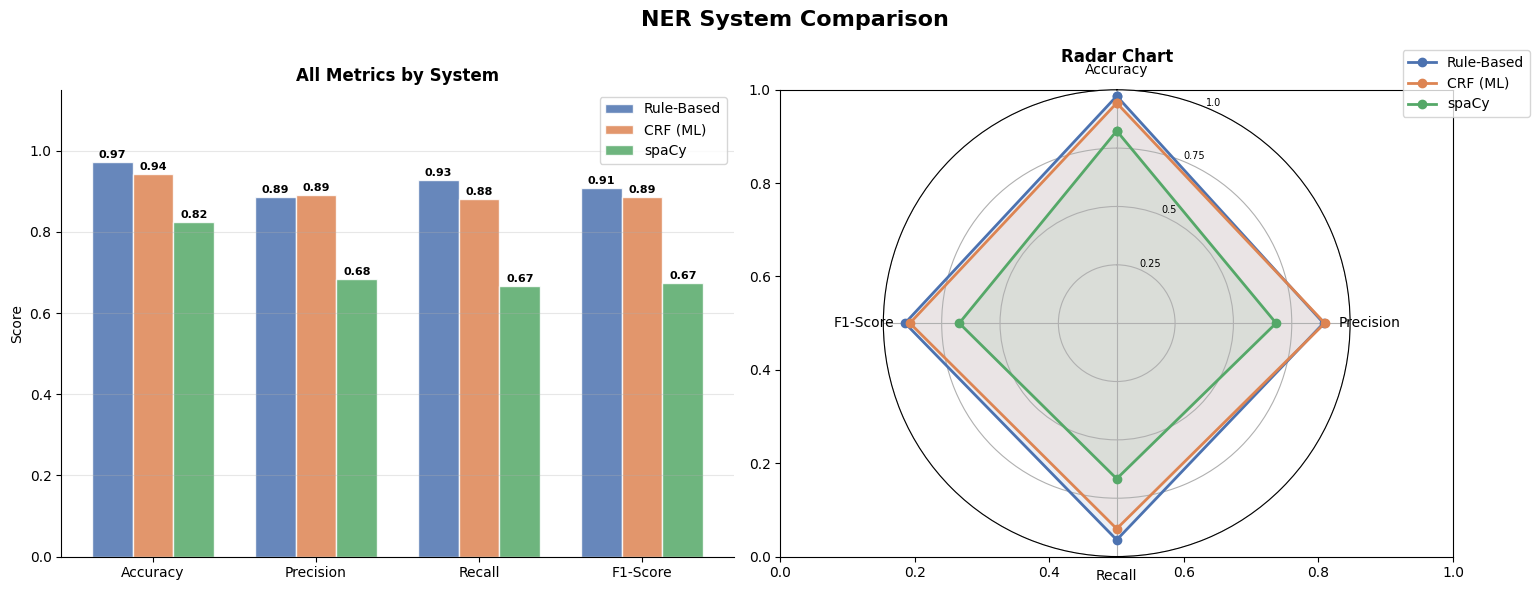

In [24]:
results = {
    'Rule-Based': rule_metrics,
    'CRF (ML)':   crf_metrics_r,
    'spaCy':      spacy_metrics,
}

df = pd.DataFrame({
    'System':    list(results.keys()),
    'Accuracy':  [r['token_accuracy'] for r in results.values()],
    'Precision': [r['precision']      for r in results.values()],
    'Recall':    [r['recall']         for r in results.values()],
    'F1-Score':  [r['f1']             for r in results.values()],
})

print("═"*70)
print("  SYSTEM COMPARISON")
print("═"*70)
print(df.to_string(index=False, float_format='{:.4f}'.format))
print(f"\n Best F1: {df.loc[df['F1-Score'].idxmax(), 'System']}")

# ── Grouped Bar Chart ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('NER System Comparison', fontsize=16, fontweight='bold')

metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x      = np.arange(len(metrics_cols))
width  = 0.25
colors = ['#4C72B0', '#DD8452', '#55A868']

ax = axes[0]
for idx, (_, row) in enumerate(df.iterrows()):
    vals = [row[m] for m in metrics_cols]
    bars = ax.bar(x + idx*width, vals, width, label=row['System'],
                  color=colors[idx], alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{v:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + width); ax.set_xticklabels(metrics_cols)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score'); ax.legend()
ax.set_title('All Metrics by System', fontweight='bold')
ax.grid(axis='y', alpha=0.3); ax.spines[['top','right']].set_visible(False)

# ── Radar Chart ──────────────────────────────────────────────────────────────
N      = len(metrics_cols)
angles = [n / N * 2 * np.pi for n in range(N)] + [0]
ax2    = plt.subplot(122, polar=True)
ax2.set_theta_offset(np.pi/2); ax2.set_theta_direction(-1)
ax2.set_xticks(angles[:-1]); ax2.set_xticklabels(metrics_cols, fontsize=10)
ax2.set_ylim(0,1); ax2.set_yticks([0.25,0.5,0.75,1.0])
ax2.set_yticklabels(['0.25','0.5','0.75','1.0'], fontsize=7)

for idx, (_, row) in enumerate(df.iterrows()):
    vals = [row[m] for m in metrics_cols] + [row[metrics_cols[0]]]
    ax2.plot(angles, vals, 'o-', lw=2, color=colors[idx], label=row['System'])
    ax2.fill(angles, vals, alpha=0.1, color=colors[idx])

ax2.set_title('Radar Chart', fontweight='bold', pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.4,1.1))

plt.tight_layout()
plt.savefig('ner_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

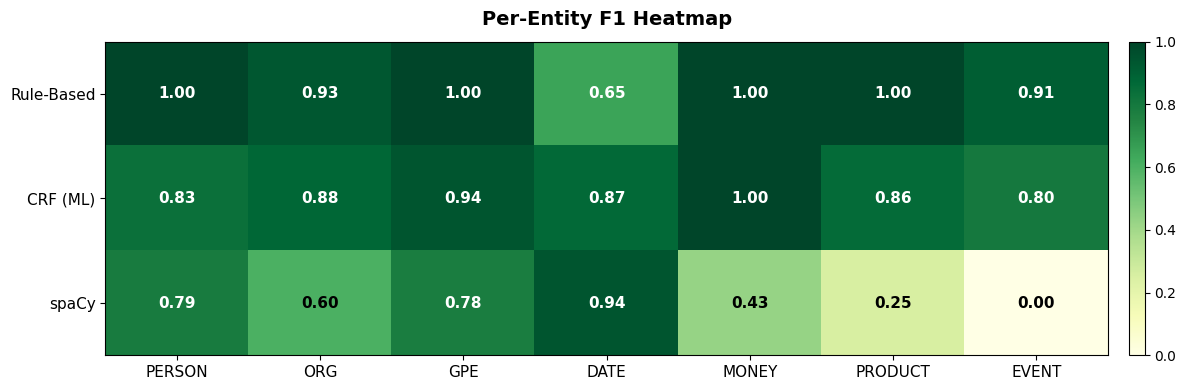

In [25]:
entity_types = ['PERSON','ORG','GPE','DATE','MONEY','PRODUCT','EVENT']
system_names = ['Rule-Based','CRF (ML)','spaCy']
preds_all    = [rule_tags, y_all_pred, spacy_tags]

def entity_f1(gold, pred, ent):
    g = [['B-'+ent if t==f'B-{ent}' else ('I-'+ent if t==f'I-{ent}' else 'O') for t in s] for s in gold]
    p = [['B-'+ent if t==f'B-{ent}' else ('I-'+ent if t==f'I-{ent}' else 'O') for t in s] for s in pred]
    try: return seq_f1(g, p)
    except: return 0.0

matrix = np.array([
    [entity_f1(gold_tags, pred, ent) for ent in entity_types]
    for pred in preds_all
])

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(matrix, cmap='YlGn', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(entity_types))); ax.set_xticklabels(entity_types, fontsize=11)
ax.set_yticks(range(len(system_names))); ax.set_yticklabels(system_names, fontsize=11)
ax.set_title('Per-Entity F1 Heatmap', fontsize=14, fontweight='bold', pad=12)
for i in range(len(system_names)):
    for j in range(len(entity_types)):
        v = matrix[i,j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                fontsize=11, fontweight='bold', color='white' if v>0.6 else 'black')
plt.colorbar(im, fraction=0.03, pad=0.02)
plt.tight_layout()
plt.savefig('ner_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
def predict_entities(text, system='spacy'):
    if system == 'rule':
        pairs = rule_ner.predict(text)
    elif system == 'crf':
        tokens = nltk.word_tokenize(text)
        pos    = nltk.pos_tag(tokens)
        sent   = [(t, p, 'O') for t, p in pos]
        feats  = sent_to_features(sent)
        preds  = crf.predict([feats])[0]
        pairs  = list(zip(tokens, preds))
    else:
        pairs  = spacy_predict_iob(text)
    return iob_to_entities(pairs)


# ── Demo ─────────────────────────────────────────────────────────────────────
demo_texts = [
    "Sundar Pichai of Google spoke at Davos in January 2024 about AI safety.",
    "LeBron James signed a $97 million deal with the Los Angeles Lakers on Friday.",
    "The EU fined Meta $1.3 billion for GDPR violations in May 2023.",
    "Elon Musk's xAI raised $6 billion in May 2024 to build a supercomputer in Memphis.",
    "Just booked flights to Tokyo for New Year's Eve — so excited!",
]

for text in demo_texts:
    print(f"\n {text}")
    print("─" * 65)
    for sys_id, sys_name in [('rule','Rule-Based'), ('crf','CRF'), ('spacy','spaCy')]:
        ents = predict_entities(text, system=sys_id)
        ent_str = " | ".join([f"[{e['label']}] {e['text']}" for e in ents]) or "None"
        print(f"  {sys_name:<12}: {ent_str}")


 Sundar Pichai of Google spoke at Davos in January 2024 about AI safety.
─────────────────────────────────────────────────────────────────
  Rule-Based  : [PERSON] Sundar Pichai | [ORG] Google | [GPE] Davos | [DATE] January | [DATE] 2024
  CRF         : [ORG] Sundar Pichai | [ORG] Google | [GPE] Davos | [DATE] January 2024
  spaCy       : [PERSON] Sundar Pichai | [GPE] Davos | [DATE] January 2024 | [GPE] AI

 LeBron James signed a $97 million deal with the Los Angeles Lakers on Friday.
─────────────────────────────────────────────────────────────────
  Rule-Based  : [MONEY] $ 97 million | [DATE] Friday
  CRF         : [ORG] LeBron James | [MONEY] $ 97 million | [GPE] Los Angeles Lakers | [DATE] Friday
  spaCy       : [PERSON] LeBron James | [MONEY] $ 97 million | [ORG] the Los Angeles Lakers | [DATE] Friday

 The EU fined Meta $1.3 billion for GDPR violations in May 2023.
─────────────────────────────────────────────────────────────────
  Rule-Based  : [ORG] Meta | [MONEY] $ 1.3 billi

In [27]:
print("\n" + "═"*70)
print("   FINAL EVALUATION SUMMARY")
print("═"*70)
print(f"  {'System':<18} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print("  " + "─"*58)
for _, row in df.iterrows():

    print(f"  {row['System']:<18} {row['Accuracy']:>10.4f} {row['Precision']:>10.4f} "
          f"{row['Recall']:>10.4f} {row['F1-Score']:>10.4f}{star}")
print("═"*70)




══════════════════════════════════════════════════════════════════════
   FINAL EVALUATION SUMMARY
══════════════════════════════════════════════════════════════════════
  System               Accuracy  Precision     Recall   F1-Score
  ──────────────────────────────────────────────────────────
  Rule-Based             0.9731     0.8864     0.9286     0.9070
  CRF (ML)               0.9433     0.8916     0.8810     0.8862
  spaCy                  0.8239     0.6829     0.6667     0.6747
══════════════════════════════════════════════════════════════════════
